In [1]:
import sys
from pyprojroot import here
sys.path.insert(0, str(here()))

In [2]:
from src.region import import_region
from src.download_utils import download_esri_satellite

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
region = import_region(here() / "notebooks" / "01_RegionStudy" / "output" / "actual_bounds.json")

In [5]:
output_img = here() / "data/satellite_imagery/satellite_texture_cropped.png"
output_bounds = here() / "data/satellite_imagery/satellite_texture_bounds_cropped.npz"

output_img.parent.mkdir(parents=True, exist_ok=True)

In [6]:
download_esri_satellite(
    region=region,
    output_img_path=output_img,
    output_bounds_path=output_bounds,
    width=2048,
    height=2048
)

Querying Esri World Imagery API with exponential backoff...
✓ Saved satellite texture to /home/admin/SkylineGeolocation/data/satellite_imagery/satellite_texture_cropped.png
✓ Saved texture bounds mapping to /home/admin/SkylineGeolocation/data/satellite_imagery/satellite_texture_bounds_cropped.npz


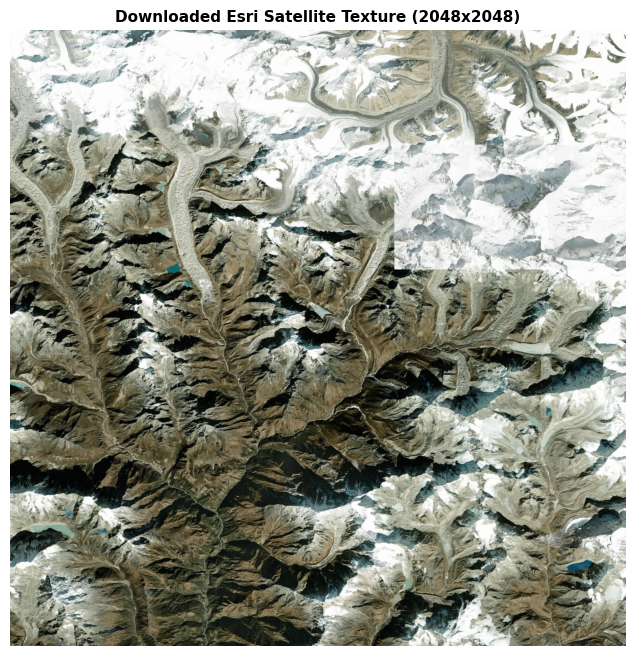

In [7]:
texture = Image.open(output_img)

plt.figure(figsize=(8, 8))
plt.imshow(texture)
plt.title("Downloaded Esri Satellite Texture (2048x2048)", fontsize=11, fontweight='bold')
plt.axis('off')
plt.show()